# Building an Insurance Claims Agent with Google ADK

**Notebook 2 of 2 — one claim from intake to outcome**

Apply the building blocks from [Notebook 1](01_ADK_Fundamentals.ipynb) to a complete claim. First, call the tools directly to see how they work. Then, let specialist agents use those tools in a workflow.

The insurance rules are simplified for teaching and must not be used for real decisions.

## The running claim

Helen Parr (`POL-100234`) strikes a pole in Bengaluru on 8 September 2026. The front bumper, left headlight, and hood are damaged. Nobody is injured.

Follow the same claim through four stages:

```text
Intake → Assessment → Escalation → Customer reply
```

![One Claim: From Intake to Outcome](Images/07_insurance_claim_journey.png)

## Who does what?

| Component | Job in this example |
|---|---|
| **Model** | Ask questions, interpret damage descriptions, write the reply |
| **Tools** | Look up facts, apply rules, calculate costs, save results |
| **Workflow** | Run the stages in order |
| **Human reviewer** | Handle cases marked for review |

**Key idea:** Check the tool results and saved state alongside the final reply.

## 1. Set up the notebook

Run `uv sync`, select the project's `.venv` kernel, and run cells from top to bottom with the project folder as the working directory.

- Add `GEMINI_API_KEY` or `GOOGLE_API_KEY` to `.env` for live agent examples.
- Without a key, or with `RUN_LLM_EXAMPLES=false`, the direct tool examples still run.

Policy and pricing data come from `local_data`. Claim state stays in memory. We use a fixed “no prior claims” snapshot to keep the example repeatable.

In [1]:
import importlib.metadata
import json
import os
from copy import deepcopy
from datetime import date
from html import escape
from pathlib import Path
from pprint import pformat, pprint

from dotenv import load_dotenv
from google.adk import Agent
from google.adk.runners import InMemoryRunner
from google.adk.tools import ToolContext
from google.genai import types
from IPython.display import HTML, Image, display

load_dotenv()

PROJECT_ROOT = Path.cwd()
MODEL = os.getenv("ADK_MODEL", "gemini-2.5-flash")
HAS_MODEL_ACCESS = bool(os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY"))
RUN_LLM_EXAMPLES = HAS_MODEL_ACCESS and os.getenv("RUN_LLM_EXAMPLES", "true").lower() == "true"

POLICIES = json.loads((PROJECT_ROOT / "local_data" / "policies.json").read_text())
PARTS_PRICING = json.loads((PROJECT_ROOT / "local_data" / "parts_pricing.json").read_text())
# Use a fixed history snapshot so repeated workshop runs follow the same example.
TEACHING_PRIOR_CLAIMS = {"CUST-5521": 0}
LABOR_RATE = 120

print("google-adk:", importlib.metadata.version("google-adk"))
print("model:", MODEL)
print("live agent examples:", RUN_LLM_EXAMPLES)
print("policyholder:", POLICIES["POL-100234"]["policyholder_name"])
print("front bumper catalog entry:", PARTS_PRICING["front_bumper"])

google-adk: 2.8.0
model: gemini-3.6-flash
live agent examples: True
policyholder: Helen Parr
front bumper catalog entry: {'part_cost': 450, 'labor_hours': 2.5}


### Helpers: run agents and read their traces

A **runner** executes the agent; a **session** holds the interaction and its state. Run this helper cell once, then focus on the examples below.

Read each execution trace as: **agent → tool call → result → state update → reply**.

In [2]:
# Runner helper: create an agent runner and a fresh in-memory session.
async def start_agent_session(agent, app_name: str, initial_state: dict | None = None):
    runner = InMemoryRunner(agent=agent, app_name=app_name)
    session = await runner.session_service.create_session(
        app_name=app_name,
        user_id="workshop-user",
        state=initial_state or {},
    )
    return runner, session


# Message helper: send text or images and return the events and updated session.
async def send_parts(runner, session, parts: list[types.Part]):
    content = types.Content(role="user", parts=parts)
    events = [
        event
        async for event in runner.run_async(
            user_id=session.user_id,
            session_id=session.id,
            new_message=content,
        )
    ]
    current = await runner.session_service.get_session(
        app_name=session.app_name,
        user_id=session.user_id,
        session_id=session.id,
    )
    return events, current


# Message helper: wrap a plain-text message for send_parts.
async def send_message(runner, session, message: str):
    return await send_parts(
        runner,
        session,
        [types.Part.from_text(text=message)],
    )


# Display helper: extract the last final response from an event list.
def final_text(events) -> str:
    for event in reversed(events):
        if event.is_final_response() and event.content:
            return "".join(part.text or "" for part in event.content.parts)
    return ""


# Display helper: shorten structured data so traces stay readable.
def _compact(value, limit: int = 900) -> str:
    rendered = pformat(value, width=92, sort_dicts=False)
    return rendered if len(rendered) <= limit else rendered[:limit] + " ..."


# Display helper: show agent activity, tool results, and state changes as a timeline.
def show_event_trace(events):
    """Display a semantic ADK timeline, including explicit agent handoffs.

    Transfer events are special: the generated function response is ``None`` because
    ADK records the destination in ``event.actions.transfer_to_agent``. Collapse that
    call/result pair into one handoff so a multi-agent run is not mistaken for a
    single-agent tool call.
    """
    steps = []
    shown_handoffs = set()

    agent_path = []
    for event in events:
        author = str(getattr(event, "author", None) or "agent")
        if not agent_path or agent_path[-1] != author:
            agent_path.append(author)

    # Display helper: add one labeled card to the execution trace.
    def add_step(kind, title, author, body, color):
        number = len(steps) + 1
        steps.append(f"""
        <div class="trace-step" style="--trace-color: {color}">
          <div class="trace-marker">{number}</div>
          <div class="trace-card">
            <div class="trace-meta">{escape(kind)} · {escape(str(author))}</div>
            <div class="trace-title">{escape(str(title))}</div>
            {body}
          </div>
        </div>""")

    # Display helper: format a labeled value for a trace card.
    def data_block(label, value):
        return (
            f'<div class="trace-label">{escape(label)}</div>'
            f'<pre>{escape(_compact(value))}</pre>'
        )

    for event in events:
        author = str(getattr(event, "author", None) or "agent")
        calls = list(event.get_function_calls())
        results = list(event.get_function_responses())
        actions = getattr(event, "actions", None)
        transfer_target = getattr(actions, "transfer_to_agent", None)

        # The call event arrives before ADK puts the destination on the response event.
        # Reading the call arguments lets the handoff appear in its true timeline slot.
        if not transfer_target:
            for call in calls:
                if call.name == "transfer_to_agent":
                    transfer_target = (call.args or {}).get("agent_name")
                    if transfer_target:
                        break

        if transfer_target:
            transfer_target = str(transfer_target)
            handoff = (author, transfer_target)
            if handoff not in shown_handoffs:
                shown_handoffs.add(handoff)
                detail = (
                    '<div class="trace-response">Control passed to the selected '
                    f'specialist: <code>{escape(transfer_target)}</code>.</div>'
                )
                add_step(
                    "AGENT HANDOFF",
                    f"{author} → {transfer_target}",
                    author,
                    detail,
                    "#0891b2",
                )

        for call in calls:
            if call.name != "transfer_to_agent":
                add_step("TOOL CALL", call.name, author, data_block("Arguments", call.args), "#2563eb")
        for result in results:
            if result.name != "transfer_to_agent":
                add_step("TOOL RESULT", result.name, author, data_block("Returned", result.response), "#7c3aed")
        state_delta = getattr(actions, "state_delta", None)
        if state_delta:
            add_step("STATE UPDATE", "Session state changed", author, data_block("Changed values", state_delta), "#d97706")
        if event.is_final_response() and event.content:
            text = "".join(part.text or "" for part in event.content.parts).strip()
            if text:
                response = f'<div class="trace-response">{escape(text)}</div>'
                add_step("FINAL RESPONSE", "Reply to customer", author, response, "#059669")

    count = len(steps)
    body = "".join(steps) or '<div class="trace-empty">No visible events in this run.</div>'
    styles = """
    <style>
      .event-trace { max-width: 900px; margin: 12px 0; color: var(--jp-content-font-color1, #172033); font-family: var(--jp-ui-font-family, system-ui, sans-serif); }
      .trace-heading { font-size: 14px; font-weight: 700; margin-bottom: 4px; }
      .trace-path { color: #475569; font-size: 12px; margin-bottom: 12px; }
      .trace-path code { font-size: 11px; }
      .trace-count, .trace-label { color: #64748b; font-weight: 600; }
      .trace-step { position: relative; display: grid; grid-template-columns: 32px 1fr; gap: 10px; padding-bottom: 12px; }
      .trace-step:not(:last-child)::before { content: ""; position: absolute; left: 14px; top: 30px; bottom: -2px; width: 2px; background: #dbe3ee; }
      .trace-marker { z-index: 1; width: 30px; height: 30px; border-radius: 50%; background: var(--trace-color); color: white; display: grid; place-items: center; font-size: 13px; font-weight: 700; }
      .trace-card { border: 1px solid #dbe3ee; border-left: 4px solid var(--trace-color); border-radius: 8px; padding: 10px 14px 12px; background: var(--jp-layout-color1, #fff); }
      .trace-meta { color: var(--trace-color); font-size: 11px; font-weight: 800; letter-spacing: .06em; }
      .trace-title { font-size: 15px; font-weight: 700; margin: 2px 0 9px; }
      .trace-label { font-size: 11px; text-transform: uppercase; margin-bottom: 4px; }
      .trace-card pre { margin: 0; padding: 9px 11px; border-radius: 6px; background: var(--jp-cell-editor-background, #f6f8fa); white-space: pre-wrap; overflow-wrap: anywhere; font-size: 12px; line-height: 1.45; }
      .trace-response { white-space: pre-wrap; line-height: 1.55; }
      .trace-empty { color: #64748b; padding: 12px; border: 1px dashed #cbd5e1; border-radius: 8px; }
    </style>
    """
    heading = f'Execution trace <span class="trace-count">· {count} {"step" if count == 1 else "steps"}</span>'
    path = " → ".join(f"<code>{escape(agent)}</code>" for agent in agent_path)
    path_html = f'<div class="trace-path">Agent path: {path}</div>' if path else ""
    display(HTML(styles + f'<div class="event-trace"><div class="trace-heading">{heading}</div>{path_html}{body}</div>'))


# Display helper: summarize the saved claim state after each stage.
def show_claim_state(state: dict, heading: str):
    print(f"\n{heading}")
    print("state keys:", " → ".join(state.keys()))
    for key in state:
        if key != "policy":
            print(f"- {key}:", _compact(state[key], limit=450))

## 2. Intake: turn answers into claim state

The first two tools save the incident details and look up the policy. Later stages read these saved facts.

For the direct calls below, `DemoToolContext` supplies a simple state dictionary. During an agent run, ADK supplies `ToolContext` with access to session state.

**Look for:** `incident` and `policy` in the printed state.

![Intake: Conversation to Structured Claim State](Images/08_intake_structured_claim_state.png)

In [3]:
# Demo helper: provide a state dictionary for tool calls outside an ADK session.
class DemoToolContext:
    """The small ToolContext surface needed for deterministic teaching calls."""

    # Demo helper: initialize the state used by the direct tool calls.
    def __init__(self, state: dict | None = None):
        self.state = state or {}


# Intake tool: save incident details and assign the tutorial claim ID.
def start_claim_intake(
    incident_date: str,
    incident_time: str,
    location: str,
    description: str,
    driver_name: str,
    is_drivable: bool,
    anyone_injured: bool,
    other_party_involved: bool,
    other_party_info: str,
    police_report_filed: bool,
    tool_context: ToolContext,
) -> dict:
    """Open the teaching claim and save the incident details supplied by the customer."""
    incident = {
        "incident_date": incident_date,
        "incident_time": incident_time,
        "location": location,
        "description": description,
        "driver_name": driver_name,
        "is_drivable": is_drivable,
        "anyone_injured": anyone_injured,
        "other_party_involved": other_party_involved,
        "other_party_info": other_party_info,
        "police_report_filed": police_report_filed,
    }
    tool_context.state.update({"claim_id": "CLM-TUTORIAL", "incident": incident})
    return {"status": "opened", "claim_id": "CLM-TUTORIAL", "incident": incident}


# Intake tool: find the policy and save it for later coverage checks.
def identify_policy(policy_number: str, tool_context: ToolContext) -> dict:
    """Look up a policy by an exact value such as POL-100234 and save a found record."""
    policy = POLICIES.get(policy_number)
    if policy is None:
        return {"status": "not_found", "policy_number": policy_number}
    tool_context.state.update({"policy_number": policy_number, "policy": policy})
    return {"status": "found", "policy_number": policy_number, "policy": policy}

In [4]:
# Walkthrough: call the intake tools directly and inspect the state they save.
claim_context = DemoToolContext()

start_claim_intake(
    incident_date="2026-09-08",
    incident_time="18:15",
    location="Bengaluru",
    description="I lost control in the rain and struck a roadside pole with the front-left side.",
    driver_name="Helen Parr",
    is_drivable=False,
    anyone_injured=False,
    other_party_involved=False,
    other_party_info="",
    police_report_filed=True,
    tool_context=claim_context,
)
identify_policy("POL-100234", claim_context)

show_claim_state(claim_context.state, "STATE AFTER INCIDENT AND POLICY INTAKE")


STATE AFTER INCIDENT AND POLICY INTAKE
state keys: claim_id → incident → policy_number → policy
- claim_id: 'CLM-TUTORIAL'
- incident: {'incident_date': '2026-09-08',
 'incident_time': '18:15',
 'location': 'Bengaluru',
 'description': 'I lost control in the rain and struck a roadside pole with the front-left '
                'side.',
 'driver_name': 'Helen Parr',
 'is_drivable': False,
 'anyone_injured': False,
 'other_party_involved': False,
 'other_party_info': '',
 'police_report_filed': True}
- policy_number: 'POL-100234'


## 3. Evidence: let an agent inspect an image

The next example sends text and image bytes together to an agent that can interpret images. Its job is to describe visible damage.

**Key idea:** A visual observation is evidence to assess; it does not establish coverage or a payout.

![Image Evidence: Observe, Don't Decide](Images/09_image_evidence_observation.png)

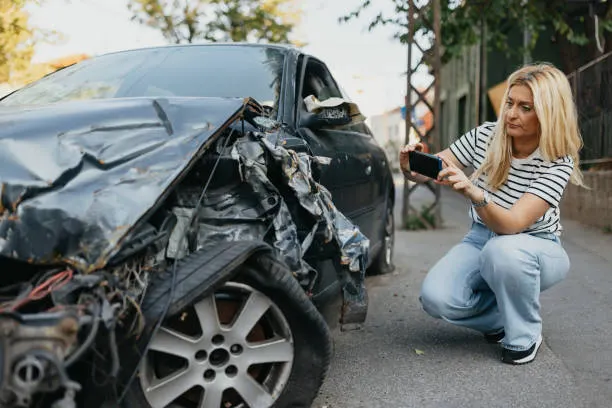

Image sent in the next cell: ./local_data/photos/CLM-93776584/1.webp


In [5]:
SAMPLE_IMAGE_PATH = (
    PROJECT_ROOT / "local_data" / "photos" / "CLM-93776584" / "1.webp"
)

display(Image(filename=str(SAMPLE_IMAGE_PATH), width=650))
print("Image sent in the next cell:", SAMPLE_IMAGE_PATH)

In [6]:
# Evidence agent: describe visible damage in the sample image.
damage_inspector_agent = Agent(
    name="damage_inspector_agent",
    model=MODEL,
    description="Describes visible vehicle damage in an uploaded image.",
    instruction="""
Inspect the supplied vehicle image. Describe only damage you can actually see.
Use 2-4 concise bullet points and ordinary part names. Do not infer how the
crash happened, decide coverage, estimate cost, or accuse the customer.
""",
)

image_question = "What vehicle damage is visibly supported by this image?"

if RUN_LLM_EXAMPLES:
    image_runner, image_session = await start_agent_session(
        damage_inspector_agent, "damage_image_demo"
    )
    image_bytes = SAMPLE_IMAGE_PATH.read_bytes()
    image_events, image_session = await send_parts(
        image_runner,
        image_session,
        [
            types.Part.from_text(text=image_question),
            types.Part.from_bytes(data=image_bytes, mime_type="image/webp"),
        ],
    )
    print("CUSTOMER:", image_question)
    show_event_trace(image_events)
else:
    print("Live image inspection skipped. Add an API key to send the displayed image.")

Direct use of automatic function calling (AFC) in AsyncModels.generate_content is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message. Similarly, direct use of AFC in AsyncModels.generate_content_stream is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message_stream.


CUSTOMER: What vehicle damage is visibly supported by this image?


### Save the evidence and its source

Keep the customer's account separate from photo observations so a reviewer can tell where each statement came from.

The two observations below are scripted stand-ins for uploaded photos; they are **not the output of the image demo**. The tool saves them under `evidence` and checks the vehicle identification number (VIN) against the policy.

In [7]:
# Evidence tool: save both damage accounts and check the VIN against the policy.
def record_damage_evidence(
    photo_descriptions: list[str],
    customer_damage_description: str,
    consistency_score: float,
    consistency_note: str,
    vin: str,
    tool_context: ToolContext,
) -> dict:
    """Save customer-reported damage and independent workshop photo observations."""
    if len(photo_descriptions) < 2:
        return {"status": "needs_more_photos", "minimum_required": 2}
    if not 0.0 <= consistency_score <= 1.0:
        return {"status": "invalid_consistency_score"}

    policy = tool_context.state.get("policy", {})
    evidence = {
        "photo_descriptions": photo_descriptions,
        "customer_damage_description": customer_damage_description,
        "consistency_score": consistency_score,
        "consistency_note": consistency_note,
        "vin": vin,
        "vin_match": policy.get("vin") == vin,
    }
    tool_context.state["evidence"] = evidence
    return {"status": "recorded", **evidence}


record_damage_evidence(
    photo_descriptions=[
        "The front bumper is crumpled on the left side.",
        "The left headlight is shattered and the hood is bent.",
    ],
    customer_damage_description=(
        "The front bumper and left headlight are broken, and the hood is bent."
    ),
    consistency_score=0.95,
    consistency_note="The observations are consistent with the reported front impact.",
    vin="1HGCM82633A004352",
    tool_context=claim_context,
)

show_claim_state(claim_context.state, "STATE AFTER COMPLETE INTAKE")


STATE AFTER COMPLETE INTAKE
state keys: claim_id → incident → policy_number → policy → evidence
- claim_id: 'CLM-TUTORIAL'
- incident: {'incident_date': '2026-09-08',
 'incident_time': '18:15',
 'location': 'Bengaluru',
 'description': 'I lost control in the rain and struck a roadside pole with the front-left '
                'side.',
 'driver_name': 'Helen Parr',
 'is_drivable': False,
 'anyone_injured': False,
 'other_party_involved': False,
 'other_party_info': '',
 'police_report_filed': True}
- policy_number: 'POL-100234'
- evidence: {'photo_descriptions': ['The front bumper is crumpled on the left side.',
                        'The left headlight is shattered and the hood is bent.'],
 'customer_damage_description': 'The front bumper and left headlight are broken, and the '
                                'hood is bent.',
 'consistency_score': 0.95,
 'consistency_note': 'The observations are consistent with the reported front impact.',
 'vin': '1HGCM82633A004352',
 'vin_mat ..

### Let the intake agent call these tools

Attach the three intake tools to one agent. The model asks for missing facts and chooses when to call them; the tools save those facts.

`mode="task"` lets intake continue across customer messages until collection is complete.

In [8]:
# Intake agent: collect missing facts across messages using the three intake tools.
intake_agent = Agent(
    name="intake_agent",
    model=MODEL,
    mode="task",
    description="Collects incident, policy, and damage evidence from the customer.",
    instruction="""
Collect one auto claim in this order:
1. Collect date, time, location, description, driver, drivability, injuries,
   other-party details, and police-report status; call start_claim_intake.
2. Collect the policy number and call identify_policy. Do not continue if not found.
3. Collect the customer's damage description, VIN, and at least two workshop
   photo observations. In this portable tutorial, those text observations stand
   in for uploaded images. Call record_damage_evidence.

Ask only for facts that are still missing. Be calm and empathetic. Never invent
claim facts or assess coverage. After all three tools succeed, finish the task
with a compact internal intake summary.
""",
    tools=[start_claim_intake, identify_policy, record_damage_evidence],
)

## 4. Assessment: combine interpretation with rules

Assessment uses the saved intake data. `mode="single_turn"` completes this stage without another customer conversation; it can still make several tool calls.

| Model interprets | Python tools check or calculate |
|---|---|
| Incident type and possible exclusions | Policy dates, coverage, listed driver, VIN |
| Damage descriptions and consistency | Prior-claim and consistency thresholds |
| Which catalog parts match the damage | Parts + labor, estimate range, policy limit |

The direct calls below supply the interpretation by hand. Look for `coverage_result`, `risk_result`, and `cost_estimate` in state.

![Assessment: Interpretation and Deterministic Rules](Images/10_assessment_interpretation_rules.png)

In [9]:
# Assessment tool: combine fixed policy checks with the supplied incident interpretation.
def verify_coverage(
    incident_type: str,
    cause_covered: bool,
    coverage_confidence: float,
    coverage_reasoning: str,
    tool_context: ToolContext,
) -> dict:
    """Apply fixed policy checks to the model's incident interpretation."""
    incident_type = incident_type.strip().lower()
    policy = tool_context.state.get("policy")
    incident = tool_context.state.get("incident")
    evidence = tool_context.state.get("evidence", {})

    if incident_type not in {"collision", "comprehensive"}:
        result = {"status": "needs_review", "reason": "Unknown incident type."}
    elif not policy or not incident:
        result = {"status": "needs_review", "reason": "Missing intake data."}
    elif not (
        date.fromisoformat(policy["effective_date"])
        <= date.fromisoformat(incident["incident_date"])
        <= date.fromisoformat(policy["expiration_date"])
    ):
        result = {"status": "not_covered", "reason": "Policy inactive on the incident date."}
    elif not policy["coverage"].get(incident_type, False):
        result = {"status": "not_covered", "reason": f"No {incident_type} coverage."}
    elif incident["driver_name"] not in policy["listed_drivers"]:
        result = {"status": "needs_review", "reason": "Driver is not listed."}
    elif evidence.get("vin_match") is not True:
        result = {"status": "needs_review", "reason": "VIN needs review."}
    elif coverage_confidence < 0.5:
        result = {"status": "needs_review", "reason": coverage_reasoning}
    elif not cause_covered:
        result = {"status": "not_covered", "reason": coverage_reasoning}
    else:
        result = {"status": "covered", "reason": coverage_reasoning}

    result["deductible"] = policy.get("coverage", {}).get("deductible") if policy else None
    tool_context.state["incident_type"] = incident_type
    tool_context.state["coverage_result"] = result
    return result


# Assessment tool: flag prior-claim and evidence-consistency signals for review.
def check_claim_history(tool_context: ToolContext) -> dict:
    """Flag simple prior-claim or evidence-consistency signals in the teaching snapshot."""
    policy = tool_context.state.get("policy", {})
    prior_claims = TEACHING_PRIOR_CLAIMS.get(policy.get("policyholder_id"), 0)
    consistency = tool_context.state.get("evidence", {}).get("consistency_score", 1.0)
    reasons = []
    if prior_claims >= 2:
        reasons.append("multiple recent claims")
    if consistency < 0.7:
        reasons.append("customer description and photo observations need comparison")
    result = {
        "risk_flag": "needs_closer_look" if reasons else "clean",
        "reason": "; ".join(reasons) if reasons else "No basic risk signals found.",
    }
    tool_context.state["risk_result"] = result
    return result


# Assessment tool: price parts and labor while retaining each part's evidence source.
def estimate_repair_cost(
    photo_confirmed_parts: list[str],
    claimed_only_parts: list[str],
    tool_context: ToolContext,
) -> dict:
    """Price catalog parts using keys such as front_bumper, headlight, and hood."""
    aliases = {
        "left_headlight": "headlight",
        "right_headlight": "headlight",
        "headlight_left": "headlight",
        "headlight_right": "headlight",
        "left_headlamp": "headlight",
        "right_headlamp": "headlight",
        "front_left_headlight": "headlight",
        "front_right_headlight": "headlight",
    }
    photo_confirmed_parts = list(dict.fromkeys(aliases.get(part, part) for part in photo_confirmed_parts))
    claimed_only_parts = list(dict.fromkeys(aliases.get(part, part) for part in claimed_only_parts))
    consistency = tool_context.state.get("evidence", {}).get("consistency_score", 1.0)
    part_provenance = {
        part: {"provenance": "photo_confirmed", "score": 1.0}
        for part in photo_confirmed_parts
    }
    for part in claimed_only_parts:
        if part not in part_provenance:
            part_provenance[part] = {
                "provenance": "claimed_only",
                "score": 1.0 if consistency >= 0.7 else consistency,
            }

    priced_parts, unknown_parts = [], []
    low_total = high_total = 0.0
    for part, provenance in part_provenance.items():
        price = PARTS_PRICING.get(part)
        if price is None:
            unknown_parts.append(part)
            continue
        subtotal = price["part_cost"] + price["labor_hours"] * LABOR_RATE
        low, high = subtotal * 0.9, subtotal * 1.25
        provenance.update({"estimated_cost_low": round(low, 2), "estimated_cost_high": round(high, 2)})
        priced_parts.append(part)
        low_total += low
        high_total += high

    policy_limit = tool_context.state.get("policy", {}).get("coverage", {}).get("limits")
    result = {
        "priced_parts": priced_parts,
        "unknown_parts": unknown_parts,
        "part_provenance": part_provenance,
        "estimated_cost_low": round(low_total, 2),
        "estimated_cost_high": round(high_total, 2),
        "policy_limit": policy_limit,
        "exceeds_limit": bool(policy_limit and high_total > policy_limit),
        "insurable_amount": min(round(high_total, 2), policy_limit) if policy_limit else round(high_total, 2),
    }
    tool_context.state["cost_estimate"] = result
    return result

In [10]:
# Assessment agent: interpret the saved claim and call the coverage, risk, and cost tools.
assessment_agent = Agent(
    name="assessment_agent",
    model=MODEL,
    mode="single_turn",
    description="Assesses coverage, risk signals, and estimated repair cost.",
    instruction="""
Assess the claim already stored in session state; do not interview the customer.
1. Interpret collision versus comprehensive and the listed exclusions, then call
   verify_coverage with your confidence and concise reasoning.
2. Unless coverage is not_covered, call check_claim_history.
3. Map visible and customer-only damage to the supported part keys, then call
   estimate_repair_cost. For this claim, use exactly these catalog keys when
   supported by the evidence: front_bumper, headlight, hood. Do not invent
   directional variants such as left_headlight.
Return a compact internal summary. Never invent tool results.
""",
    tools=[verify_coverage, check_claim_history, estimate_repair_cost],
)

In [11]:
# Walkthrough: supply sample interpretations directly, then inspect the assessment results.
coverage = verify_coverage(
    incident_type="collision",
    cause_covered=True,
    coverage_confidence=0.95,
    coverage_reasoning="The reported pole impact is a collision and no listed exclusion is indicated.",
    tool_context=claim_context,
)
risk = check_claim_history(claim_context)
cost = estimate_repair_cost(
    photo_confirmed_parts=["front_bumper", "headlight", "hood"],
    claimed_only_parts=[],
    tool_context=claim_context,
)

print("ASSESSMENT RESULTS")
pprint({"coverage": coverage, "risk": risk, "cost": cost})
show_claim_state(claim_context.state, "STATE AFTER ASSESSMENT")

ASSESSMENT RESULTS
{'cost': {'estimated_cost_high': 2437.5,
          'estimated_cost_low': 1755.0,
          'exceeds_limit': False,
          'insurable_amount': 2437.5,
          'part_provenance': {'front_bumper': {'estimated_cost_high': 937.5,
                                               'estimated_cost_low': 675.0,
                                               'provenance': 'photo_confirmed',
                                               'score': 1.0},
                              'headlight': {'estimated_cost_high': 300.0,
                                            'estimated_cost_low': 216.0,
                                            'provenance': 'photo_confirmed',
                                            'score': 1.0},
                              'hood': {'estimated_cost_high': 1200.0,
                                       'estimated_cost_low': 864.0,
                                       'provenance': 'photo_confirmed',
                                       '

## 5. Escalation: choose the next action

Three tools run in order: **classify priority → recommend an action → package the outcome**.

The teaching rules auto-approve low-priority claims and mark other cases `pending_review`. For approval, the amount is the estimate midpoint minus the deductible, with a minimum of zero.

The reply agent explains the packaged outcome. For pending review, it keeps the internal recommendation out of the customer message.

![Escalation: Where Automation Meets Human Review](Images/11_human_automation_boundary.png)

In [13]:
# Escalation tool: assign priority from saved coverage, risk, and cost results.
def classify_claim_priority(tool_context: ToolContext) -> dict:
    """Classify the claim using coverage, risk, and cost already stored in state."""
    coverage = tool_context.state.get("coverage_result", {})
    risk = tool_context.state.get("risk_result", {})
    cost = tool_context.state.get("cost_estimate", {})
    high = cost.get("estimated_cost_high", 0)
    limit = cost.get("policy_limit", 0)

    if coverage.get("status") != "covered" or risk.get("risk_flag") != "clean":
        result = {"priority": "high", "reason": "Coverage or risk requires review."}
    elif limit and high > limit * 0.5:
        result = {"priority": "high", "reason": "Cost is high relative to the policy limit."}
    elif limit and high > limit * 0.1:
        result = {"priority": "medium", "reason": "Cost exceeds the low-priority range."}
    else:
        result = {
            "priority": "low",
            "reason": "Coverage, risk, and cost are within the simple-claim range.",
        }
    tool_context.state["priority_result"] = result
    return result


# Escalation tool: recommend an approval amount for low priority or request review.
def recommend_decision(tool_context: ToolContext) -> dict:
    """Create an approval recommendation for a low claim or request manual review."""
    priority = tool_context.state.get("priority_result", {})
    cost = tool_context.state.get("cost_estimate", {})
    deductible = tool_context.state.get("coverage_result", {}).get("deductible", 0)
    if priority.get("priority") == "low":
        midpoint = (cost["estimated_cost_low"] + cost["estimated_cost_high"]) / 2
        result = {
            "recommended_action": "approve",
            "recommended_amount": round(max(0, midpoint - deductible), 2),
        }
    else:
        result = {"recommended_action": "needs_manual_review", "recommended_amount": None}
    tool_context.state["recommendation"] = result
    return result


# Escalation tool: save the approval or pending-review outcome in claim_package.
def package_for_adjuster(tool_context: ToolContext) -> dict:
    """Create an in-memory outcome package without writing shared repository data."""
    priority = tool_context.state.get("priority_result", {})
    recommendation = tool_context.state.get("recommendation", {})
    auto_approved = (
        priority.get("priority") == "low"
        and recommendation.get("recommended_action") == "approve"
    )
    package = {
        "claim_id": tool_context.state.get("claim_id"),
        "status": "auto_approved" if auto_approved else "pending_review",
        "priority": priority.get("priority"),
        "auto_approved": auto_approved,
        "approved_amount": recommendation.get("recommended_amount") if auto_approved else None,
        "deductible": tool_context.state.get("coverage_result", {}).get("deductible"),
        "claimed_only_parts": [
            part
            for part, details in tool_context.state.get("cost_estimate", {})
            .get("part_provenance", {})
            .items()
            if details.get("provenance") == "claimed_only"
        ],
    }
    tool_context.state["claim_package"] = package
    return package

In [14]:
# Escalation agent: run priority, recommendation, and packaging tools in order.
escalation_agent = Agent(
    name="escalation_agent",
    model=MODEL,
    mode="single_turn",
    description="Classifies the claim and packages its next action.",
    instruction=(
        "Use existing claim state. Call classify_claim_priority, recommend_decision, "
        "and package_for_adjuster in that order. Report the returned package fields. "
        "For pending_review, never reveal the internal recommendation."
    ),
    tools=[classify_claim_priority, recommend_decision, package_for_adjuster],
)

# Reply agent: turn the escalation outcome into a customer-facing update.
reply_agent = Agent(
    name="reply_agent",
    model=MODEL,
    mode="single_turn",
    description="Composes the final customer-facing claim update.",
    instruction="""
Compose the customer message using only the incoming escalation outcome.
- For auto_approved, state the approval, approved amount, and deductible.
- For pending_review, say the claims team will review it; do not reveal an
  internal recommendation or promise a timeline.
- Mention claimed-only parts neutrally if present.
Be empathetic and add no new policy, pricing, or claim facts.
""",
)

In [15]:
# Walkthrough: turn the saved assessment into an outcome package.
priority = classify_claim_priority(claim_context)
recommendation = recommend_decision(claim_context)
package = package_for_adjuster(claim_context)

print("ESCALATION RESULTS")
pprint({"priority": priority, "recommendation": recommendation, "package": package})
show_claim_state(claim_context.state, "STATE AFTER ESCALATION")

ESCALATION RESULTS
{'package': {'approved_amount': 1596.25,
             'auto_approved': True,
             'claim_id': 'CLM-TUTORIAL',
             'claimed_only_parts': [],
             'deductible': 500,
             'priority': 'low',
             'status': 'auto_approved'},
 'priority': {'priority': 'low',
              'reason': 'Coverage, risk, and cost are within the simple-claim '
                        'range.'},
 'recommendation': {'recommended_action': 'approve',
                    'recommended_amount': 1596.25}}

STATE AFTER ESCALATION
state keys: claim_id → incident → policy_number → policy → evidence → incident_type → coverage_result → risk_result → cost_estimate → priority_result → recommendation → claim_package
- claim_id: 'CLM-TUTORIAL'
- incident: {'incident_date': '2026-09-08',
 'incident_time': '18:15',
 'location': 'Bengaluru',
 'description': 'I lost control in the rain and struck a roadside pole with the front-left '
                'side.',
 'driver_name': '

## 6. Connect the stages with a workflow

```text
START → Intake → Assessment → Escalation → Reply
```

Intake can wait for another customer message. The adapter below resumes that task and holds the next stage until intake finishes.

**Key idea:** The workflow sets the stage order; each agent chooses tool calls within its stage.

![Complete Controlled Claims Workflow](Images/12_complete_claims_workflow.png)

In [16]:
from google.adk.agents.context import Context
from google.adk.workflow import START, Workflow, node


# Workflow node: make the intake agent runnable inside the graph.
_intake_node = node(intake_agent)


# Workflow helper: resume the intake task and pause this stage while it awaits input.
async def _intake_dispatch_fn(ctx: Context, node_input):
    return await ctx.run_node(
        _intake_node,
        node_input=node_input,
        run_id="intake",
        override_isolation_scope="intake",
        raise_on_wait=True,
    )


# Workflow adapter: rerun the intake wrapper when another customer message arrives.
intake_dispatch = node(
    _intake_dispatch_fn,
    name="intake_dispatch",
    rerun_on_resume=True,
)
# Hold assessment until the intake wrapper produces its completed output.
intake_dispatch.wait_for_output = True

# Workflow: require intake, assessment, escalation, and reply in this order.
tutorial_claims_workflow = Workflow(
    name="tutorial_claims_workflow",
    edges=[(START, intake_dispatch, assessment_agent, escalation_agent, reply_agent)],
)

print("WORKFLOW")
print(" → ".join(workflow_node.name for workflow_node in tutorial_claims_workflow.graph.nodes))

WORKFLOW
__START__ → intake_dispatch → assessment_agent → escalation_agent → reply_agent


## 7. Run the complete workflow

Start a **new, empty session**. The earlier `claim_context` is not reused: agents now call the same tools to build state from customer messages.

The first message opens the conversation; the second supplies all sample claim details, including the two scripted photo observations.

**Look for:** intake questions → tool calls and state updates → specialist transitions → final reply and claim receipt.

In [17]:
# Live example: let agents rebuild the claim from these messages in a fresh session.
scripted_customer_messages = [
    "I need to open an auto claim.",
    """The accident was on 2026-09-08 at 18:15 in Bengaluru. I, Helen Parr,
was driving and lost control in the rain, striking a roadside pole with the
front-left side. The car is not drivable, nobody was injured, no other party
was involved, and I filed a police report. My policy is POL-100234 and the VIN
is 1HGCM82633A004352. In my own words, the front bumper and left headlight are
broken and the hood is bent. Workshop photo observation 1: the front bumper is
crumpled on the left side. Workshop photo observation 2: the left headlight is
shattered and the hood is bent.""",
]

if RUN_LLM_EXAMPLES:
    workflow_runner = InMemoryRunner(
        node=tutorial_claims_workflow,
        app_name="tutorial_claims_end_to_end",
    )
    workflow_session = await workflow_runner.session_service.create_session(
        app_name="tutorial_claims_end_to_end",
        user_id="workshop-user",
    )

    complete_run_events = []
    for turn_number, customer_message in enumerate(scripted_customer_messages, start=1):
        print(f"\n{'=' * 16} CUSTOMER TURN {turn_number} {'=' * 16}")
        print(customer_message)
        turn_events, workflow_session = await send_message(
            workflow_runner,
            workflow_session,
            customer_message,
        )
        complete_run_events.extend(turn_events)
        show_event_trace(turn_events)

    print("\n" + "=" * 18 + " FINAL CLAIM RECEIPT " + "=" * 18)
    receipt = {
        "claim_id": workflow_session.state.get("claim_id"),
        "status": workflow_session.state.get("claim_package", {}).get("status"),
        "coverage": workflow_session.state.get("coverage_result", {}).get("status"),
        "estimated_cost": {
            "low": workflow_session.state.get("cost_estimate", {}).get("estimated_cost_low"),
            "high": workflow_session.state.get("cost_estimate", {}).get("estimated_cost_high"),
        },
        "approved_amount": workflow_session.state.get("claim_package", {}).get("approved_amount"),
        "deductible": workflow_session.state.get("claim_package", {}).get("deductible"),
    }
    pprint(receipt)
    print("\nState accumulated in this order:")
    print(" → ".join(workflow_session.state.keys()))
else:
    print(
        "Live end-to-end run skipped. Add GEMINI_API_KEY/GOOGLE_API_KEY and "
        "set RUN_LLM_EXAMPLES=true, then rerun this cell."
    )


================ CUSTOMER TURN 1 ================
I need to open an auto claim.


./.venv/lib/python3.12/site-packages/google/adk/models/llm_request.py:298: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR_FUNC_DECL is enabled.
  declaration = tool._get_declaration()



================ CUSTOMER TURN 2 ================
The accident was on 2026-09-08 at 18:15 in Bengaluru. I, Helen Parr,
was driving and lost control in the rain, striking a roadside pole with the
front-left side. The car is not drivable, nobody was injured, no other party
was involved, and I filed a police report. My policy is POL-100234 and the VIN
is 1HGCM82633A004352. In my own words, the front bumper and left headlight are
broken and the hood is bent. Workshop photo observation 1: the front bumper is
crumpled on the left side. Workshop photo observation 2: the left headlight is
shattered and the hood is bent.



================== FINAL CLAIM RECEIPT ==================
{'approved_amount': 1596.25,
 'claim_id': 'CLM-TUTORIAL',
 'coverage': 'covered',
 'deductible': 500,
 'estimated_cost': {'high': 2437.5, 'low': 1755.0},
 'status': 'auto_approved'}

State accumulated in this order:
claim_id → incident → policy_number → policy → evidence → incident_type → coverage_result → risk_result → cost_estimate → priority_result → recommendation → claim_package


### Check the result

Compare the final receipt with the trace: the coverage result comes from assessment, and the status and approved amount come from `claim_package`.

**Key idea:** Shared state carries results between stages; events show which agent and tool produced them.

## 8. Extend the tutorial

The same four stages can support a larger application. Next steps include:

- Persist claim state and history across runs.
- Replace scripted observations with uploaded photos and stored image references.
- Expand coverage checks and connect pending claims to a human review queue.

## Key takeaways

- **Agents** interpret requests and choose among their tools.
- **Tools** retrieve facts, apply rules, and save structured results.
- **State** carries those results through the claim.
- **Workflows** control stage order and wait for unfinished intake.
- **Events** make each step visible.
- **Customer replies** communicate the packaged outcome.